# MEKE diagnostics — single monthly snapshot (0001-01)

2D maps and zonal averages of `MEKE`, `MEKE_GM_src` and vertically-integrated `FrictWork`
for all `coupled_bANN_1.0*` experiments in the archive.

Data is read directly (no helper classes). Only these files are used per experiment:
- `*.mom6.h.native.0001-01.nc` (MEKE, MEKE_GM_src)
- `*.mom6.h.z.0001-01.nc` (FrictWork)

Grid information (`geolon`, `geolat`, `wet`) comes from `*.mom6.h.ocean_geometry.nc`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import glob
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean

%matplotlib inline
plt.rcParams.update({'font.size': 13})

In [14]:
# Find all coupled_bANN_1.0* experiments in the archive
ARCHIVE = '/glade/derecho/scratch/pavelp/archive'


# Average over all monthly snapshots in this inclusive range (year, month).SNAP = f'{snaps[0]}_to_{snaps[-1]}'  # label used in plot titles / filenames

START = (1, 1)   # 0001-01         if START <= (y, m) <= END]

END = (4, 12)    # 0004-12         for y in range(START[0], END[0] + 1) for m in range(1, 13)
snaps = [f'{y:04d}-{m:02d}' for y in range(1,5) for m in range(1,13)]

In [24]:
# Load grid geometry once (all experiments share the same grid).
# geolat/geolon/wet are on (lath, lonh) -> rename to (yh, xh) to match the data.
geom_file = f'{ARCHIVE}/coupled_bANN_1.0/ocn/hist/coupled_bANN_1.0.mom6.h.ocean_geometry.nc'
grd = xr.open_dataset(geom_file)

geolon = grd.geolon.rename({'lath': 'yh', 'lonh': 'xh'}).compute()
geolat = grd.geolat.rename({'lath': 'yh', 'lonh': 'xh'}).compute()
wet = grd.wet.rename({'lath': 'yh', 'lonh': 'xh'}).compute()
ocean = xr.where(wet > 0, 1.0, np.nan).compute()  # 1 over ocean, NaN over land

In [18]:
def zonal_ave(array, geolat):
    """Bin a 2D field into ~1-degree latitude bands using geolat (works on tripolar grids)."""
    bins = array.yh.values
    bins = (bins[0:-1] + bins[1:]) / 2
    return array.groupby_bins(geolat, bins=bins).mean()


def za_line(a):
    """Zonally-averaged 1D profile (value, latitude) from a 2D field."""
    z = zonal_ave(a, geolat)
    lat = np.array([iv.mid for iv in z.geolat_bins.values])
    return z.values, lat

In [19]:
# Read every monthly snapshot in `snaps` and time-average per experiment.
# MEKE, MEKE_GM_src come from the native files; FrictWork from the z files
# (per-layer work in W m-2, vertically integrated to a column total).
MEKE = {}
MEKE_GM_src = {}
FrictWork = {}

OLD = 'coupled_bANN_1.0'               # old code
NEW = 'coupled_bANN_1.0_slopes_0.01'   # new code
experiments = [OLD, NEW]

for exp in experiments:
    hist = f'{ARCHIVE}/{exp}/ocn/hist'
    nfiles = [f'{hist}/{exp}.mom6.h.native.{s}.nc' for s in snaps]
    zfiles = [f'{hist}/{exp}.mom6.h.z.{s}.nc' for s in snaps]
    dsn = xr.open_mfdataset(nfiles, combine='nested', concat_dim='time')
    dsz = xr.open_mfdataset(zfiles, combine='nested', concat_dim='time')

    MEKE[exp] = (dsn.MEKE.mean('time') * ocean).compute()
    MEKE_GM_src[exp] = (dsn.MEKE_GM_src.mean('time') * ocean).compute()
    # min_count=1 keeps all-NaN (land) columns as NaN so they render as land, not 0.
    FrictWork[exp] = (dsz.FrictWork.sum('z_l', min_count=1).mean('time') * ocean).compute()

    print(f'{exp}: averaged {len(snaps)} months ({snaps[0]}..{snaps[-1]})')# New data -> drop any cached zonal averages so downstream plots recompute.


coupled_bANN_1.0: averaged 48 months (0001-01..0004-12)
coupled_bANN_1.0_slopes_0.01: averaged 48 months (0001-01..0004-12)


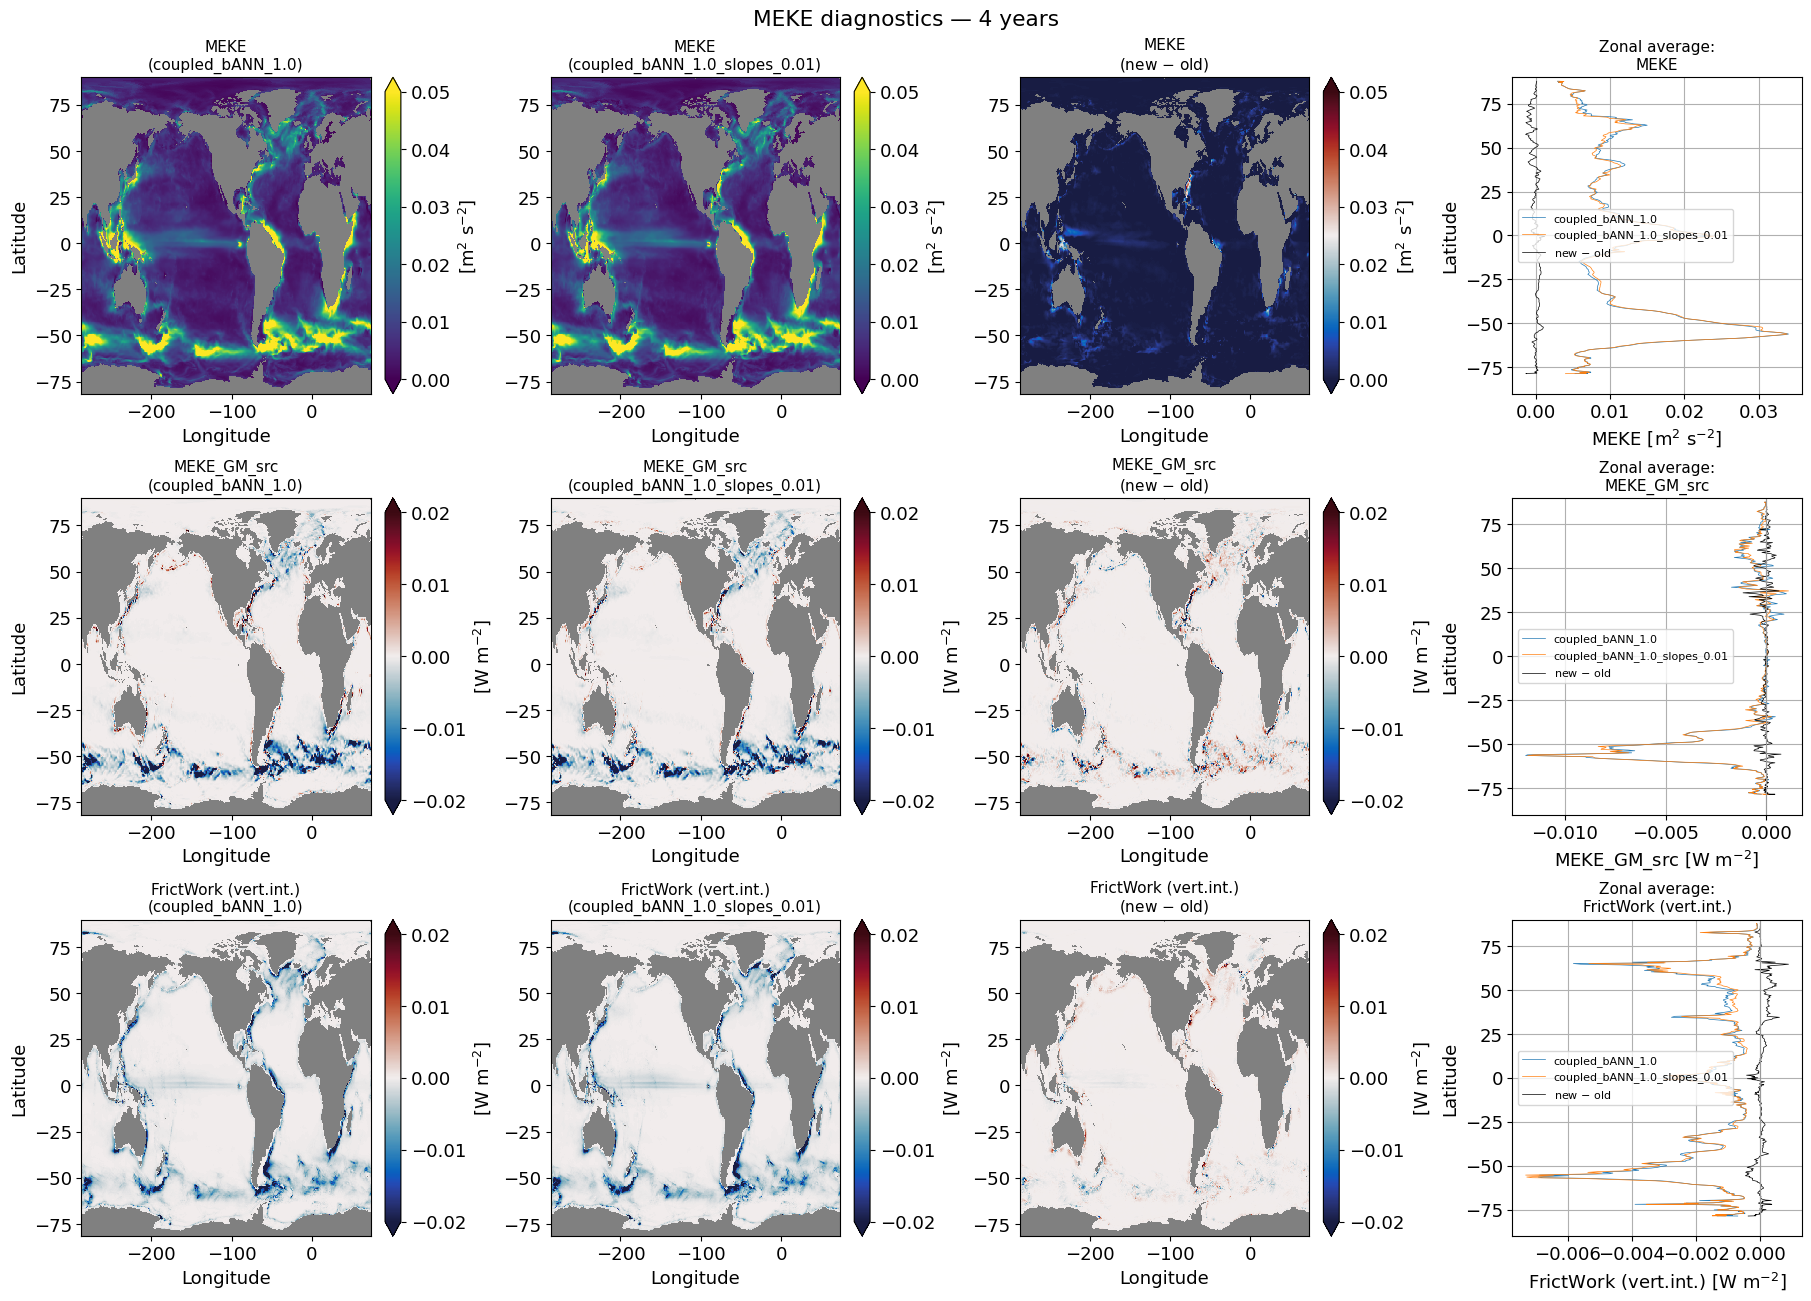

In [30]:
# Maps (one column per experiment) + a difference column + a zonal-average column,
# one row per quantity.
# name, field dict, units, cmap, (vmin, vmax)
quantities = [
    ('MEKE',                  MEKE,        r'm$^2$ s$^{-2}$', 'viridis',          (0, 0.05)),
    ('MEKE_GM_src',           MEKE_GM_src, r'W m$^{-2}$',     cmocean.cm.balance, (-0.02, 0.02)),
    ('FrictWork (vert.int.)', FrictWork,   r'W m$^{-2}$',     cmocean.cm.balance, (-0.02, 0.02)),
]

OLD = 'coupled_bANN_1.0'               # old code
NEW = 'coupled_bANN_1.0_slopes_0.01'   # new code
experiments = [OLD, NEW]
labels = experiments

n_exp = len(experiments)
n_col = n_exp + 2  # map per experiment + difference map + zonal-average column
n_row = len(quantities)
fig, axes = plt.subplots(n_row, n_col, figsize=(4.5 * n_col, 4.3 * n_row), layout='constrained')
axes = np.atleast_2d(axes)

for i, (name, fields, units, cmap, vlim) in enumerate(quantities):
    vmin, vmax = vlim
    is_div = cmap != 'viridis'

    # 2D maps for each experiment
    for j, (exp, lab) in enumerate(zip(experiments, labels)):
        ax = axes[i, j]
        ax.set_facecolor('gray')  # gray land shading (NaN cells)
        pm = ax.pcolormesh(geolon, geolat, fields[exp], cmap=cmap,
                           vmin=vmin, vmax=vmax, shading='auto')
        fig.colorbar(pm, ax=ax, label=f'[{units}]', extend='both')
        ax.set_title(f'{name}\n({lab})', fontsize=11)
        ax.set_xlabel('Longitude')
        if j == 0:
            ax.set_ylabel('Latitude')

    # Difference map: new code - old code
    diff = fields[NEW] - fields[OLD]
    ax = axes[i, n_exp]
    ax.set_facecolor('gray')
    pm = ax.pcolormesh(geolon, geolat, diff, cmap=cmocean.cm.balance,
                       vmin=vmin, vmax=vmax, shading='auto')
    fig.colorbar(pm, ax=ax, label=f'[{units}]', extend='both')
    ax.set_title(f'{name}\n(new $-$ old)', fontsize=11)
    ax.set_xlabel('Longitude')

    # Zonally-averaged profile
    ax = axes[i, n_col - 1]
    for exp, lab in zip(experiments, labels):
        v, lat = za_line(fields[exp])
        ax.plot(v, lat, label=lab, lw=0.5)
    v, lat = za_line(diff)
    ax.plot(v, lat, 'k-', label='new $-$ old', lw=0.5)
    if is_div:
        ax.axvline(0, color='0.6', lw=0.8)
    ax.set_xlabel(f'{name} [{units}]')
    ax.set_ylabel('Latitude')
    ax.set_ylim([-90, 90])
    ax.set_title(f'Zonal average:\n{name}', fontsize=11)
    ax.grid(True)
    ax.legend(fontsize=8, loc='center left')

fig.suptitle(f'MEKE diagnostics — 4 years')
plt.savefig(f'PNG_coupled_55years/MEKE_4_years_coupled_bANN_1.0_{NEW}.png', dpi=200, bbox_inches='tight')
plt.show()
